# KV Cache Optimization Analysis
### Empirical Study: LLaMA 3.2 1B vs IBM Granite 3.0 2B vs Qwen 2.5 1.5B

**Paper:** Why KV Cache Optimization Methods Fail on Non-LLaMA Architectures  
**Author:** Navaneeth Singh

---
**Models:**
- `meta-llama/Llama-3.2-1B` — control (KV cache works well)
- `ibm-granite/granite-3.0-2b-base` — case study 1
- `Qwen/Qwen2.5-1.5B` — case study 2

**KV Cache Methods:**
- Baseline (full KV cache, no optimization)
- H2O (Heavy Hitter Oracle) — evicts non-heavy-hitter tokens
- SnapKV — clusters and compresses KV cache

**Metrics:**
- Perplexity on WikiText-2
- Memory usage (MB)
- Throughput (tokens/sec)
- Performance degradation % vs baseline

## Step 1 — Mount Google Drive (saves models so you don't re-download every session)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
MODEL_CACHE_DIR = '/content/models'
RESULTS_DIR = '/content/results'
os.makedirs(MODEL_CACHE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

DRIVE_RESULTS = '/content/drive/MyDrive/kvcache_research/results'
os.makedirs(DRIVE_RESULTS, exist_ok=True)

print(f'Model cache: {MODEL_CACHE_DIR}')
print(f'Results dir: {RESULTS_DIR}')

Mounted at /content/drive
Model cache: /content/models
Results dir: /content/results


## Step 2 — Install Dependencies

In [2]:
!pip install -q transformers==4.47.0 accelerate datasets torch bitsandbytes
!pip install -q snapkv  # SnapKV implementation
print('Dependencies installed.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 93.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 118.4 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement snapkv (from versions: none)
ERROR: No matching distribution found for snapkv
Dependencies installed.


## Step 3 — HuggingFace Login (needed for LLaMA — gated model)

In [3]:
# You need to accept LLaMA 3.2 license at:
# https://huggingface.co/meta-llama/Llama-3.2-1B
# Then create a token at https://huggingface.co/settings/tokens

from huggingface_hub import login
login()  # paste your HF token when prompted

## Step 4 — GPU Check

In [3]:
import torch

print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: No GPU detected. Go to Runtime > Change runtime type > T4 GPU')

CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB


## Step 5 — Download and Cache Models

In [15]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import os

# Force clear cache to ensure clean reload if possible
if 'models' in globals():
    del models
    torch.cuda.empty_cache()

MODELS = {
    'opt':     'facebook/opt-1.3b',
    'granite': 'ibm-granite/granite-3.0-2b-base',
    'qwen':    'Qwen/Qwen2.5-1.5B',
}

tokenizers = {}
models = {}

for name, model_id in MODELS.items():
    print(f'Loading {name} ({model_id})...')
    tokenizers[name] = AutoTokenizer.from_pretrained(
        model_id,
        cache_dir=MODEL_CACHE_DIR,
        trust_remote_code=True
    )
    models[name] = AutoModelForCausalLM.from_pretrained(
        model_id,
        cache_dir=MODEL_CACHE_DIR,
        torch_dtype=torch.float16,
        device_map='auto',
        trust_remote_code=True,
        attn_implementation='eager'
    )
    models[name].eval()
    print(f'  {name} loaded. ✓')

print('\nAll models re-loaded with Eager attention.')

Loading opt (facebook/opt-1.3b)...
  opt loaded. ✓
Loading granite (ibm-granite/granite-3.0-2b-base)...


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

  granite loaded. ✓
Loading qwen (Qwen/Qwen2.5-1.5B)...
  qwen loaded. ✓

All models loaded.


## Step 6 — Load WikiText-2 Dataset

In [5]:
from datasets import load_dataset

dataset = load_dataset('wikitext', 'wikitext-2-raw-v1', split='test')
# Use first 500 non-empty samples for speed
texts = [t for t in dataset['text'] if len(t.strip()) > 50][:500]
print(f'Loaded {len(texts)} test samples')
print(f'Example: {texts[0][:100]}...')

README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Loaded 500 test samples
Example:  Robert Boulter is an English film , television and theatre actor . He had a guest @-@ starring role...


## Step 7 — Perplexity Measurement Function

In [6]:
import torch
import numpy as np
import time

def measure_perplexity(model, tokenizer, texts, max_length=512, stride=256):
    """
    Compute perplexity using sliding window approach.
    Returns perplexity, avg memory usage (MB), avg throughput (tokens/sec)
    """
    model.eval()
    nlls = []
    memory_usage = []
    throughput_list = []

    with torch.no_grad():
        for text in texts[:100]:  # use 100 samples for speed
            encodings = tokenizer(text, return_tensors='pt', truncation=True,
                                  max_length=max_length).to('cuda')
            input_ids = encodings['input_ids']

            if input_ids.shape[1] < 10:
                continue

            torch.cuda.reset_peak_memory_stats()
            start = time.time()

            outputs = model(input_ids, labels=input_ids)
            loss = outputs.loss

            elapsed = time.time() - start
            mem = torch.cuda.max_memory_allocated() / 1e6  # MB
            tps = input_ids.shape[1] / elapsed

            nlls.append(loss.item())
            memory_usage.append(mem)
            throughput_list.append(tps)

    ppl = np.exp(np.mean(nlls))
    avg_mem = np.mean(memory_usage)
    avg_tps = np.mean(throughput_list)
    return ppl, avg_mem, avg_tps

## Step 8 — H2O KV Cache Implementation

In [7]:
class H2OKVCache:
    """
    Simplified H2O (Heavy Hitter Oracle) KV cache eviction.
    Keeps top-k tokens by cumulative attention score (heavy hitters)
    plus a recent window.
    """
    def __init__(self, heavy_ratio=0.1, recent_ratio=0.1):
        self.heavy_ratio = heavy_ratio  # fraction of heavy hitter tokens to keep
        self.recent_ratio = recent_ratio  # fraction of recent tokens to keep
        self.attn_scores = None

    def update_scores(self, attn_weights):
        # attn_weights: [batch, heads, seq, seq]
        scores = attn_weights.sum(dim=(0, 1, 2))  # sum over batch, heads, queries
        if self.attn_scores is None:
            self.attn_scores = scores
        else:
            min_len = min(len(self.attn_scores), len(scores))
            self.attn_scores = self.attn_scores[:min_len] + scores[:min_len]

    def get_eviction_mask(self, seq_len):
        if self.attn_scores is None:
            return torch.ones(seq_len, dtype=torch.bool)

        n_heavy = max(1, int(seq_len * self.heavy_ratio))
        n_recent = max(1, int(seq_len * self.recent_ratio))

        scores = self.attn_scores[:seq_len]
        heavy_indices = torch.topk(scores, n_heavy).indices
        recent_indices = torch.arange(seq_len - n_recent, seq_len)

        mask = torch.zeros(seq_len, dtype=torch.bool)
        mask[heavy_indices] = True
        mask[recent_indices] = True
        return mask

    def reset(self):
        self.attn_scores = None

print('H2O KV Cache defined.')

H2O KV Cache defined.


## Step 9 — Measure Perplexity Under KV Cache Budget
Simulate KV cache compression by limiting the effective context window

In [8]:
def measure_perplexity_with_budget(model, tokenizer, texts,
                                    max_length=512, kv_budget_ratio=0.5):
    """
    Simulate KV cache compression by using only a fraction of the context.
    kv_budget_ratio=1.0 means full cache (baseline)
    kv_budget_ratio=0.5 means keep only 50% of tokens
    """
    model.eval()
    nlls = []
    memory_usage = []

    effective_length = max(32, int(max_length * kv_budget_ratio))

    with torch.no_grad():
        for text in texts[:100]:
            encodings = tokenizer(text, return_tensors='pt', truncation=True,
                                  max_length=effective_length).to('cuda')
            input_ids = encodings['input_ids']

            if input_ids.shape[1] < 10:
                continue

            torch.cuda.reset_peak_memory_stats()
            outputs = model(input_ids, labels=input_ids)
            loss = outputs.loss
            mem = torch.cuda.max_memory_allocated() / 1e6

            nlls.append(loss.item())
            memory_usage.append(mem)

    ppl = np.exp(np.mean(nlls))
    avg_mem = np.mean(memory_usage)
    return ppl, avg_mem

print('Budget-based eval function defined.')

Budget-based eval function defined.


## Step 10 — Run Full Experiments
This is the core experiment loop. Runs all models × all KV budgets.

In [9]:
import pandas as pd

KV_BUDGETS = [1.0, 0.75, 0.5, 0.25]  # 100%, 75%, 50%, 25% of full cache
results = []

for model_name in MODELS.keys():
    print(f'\n=== {model_name.upper()} ===')
    model = models[model_name]
    tokenizer = tokenizers[model_name]

    # Ensure pad token exists
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    for budget in KV_BUDGETS:
        label = 'Baseline' if budget == 1.0 else f'KV {int(budget*100)}%'
        print(f'  Running {label}...')

        ppl, mem = measure_perplexity_with_budget(
            model, tokenizer, texts,
            max_length=512,
            kv_budget_ratio=budget
        )

        results.append({
            'model': model_name,
            'kv_budget': budget,
            'label': label,
            'perplexity': round(ppl, 3),
            'memory_mb': round(mem, 1),
        })
        print(f'    Perplexity: {ppl:.3f} | Memory: {mem:.1f} MB')

df = pd.DataFrame(results)
print('\n=== RESULTS ===')
print(df.to_string(index=False))


=== OPT ===
  Running Baseline...
    Perplexity: 32.645 | Memory: 10914.0 MB
  Running KV 75%...
    Perplexity: 32.646 | Memory: 10913.7 MB
  Running KV 50%...
    Perplexity: 33.121 | Memory: 10904.1 MB
  Running KV 25%...
    Perplexity: 37.428 | Memory: 10872.3 MB

=== GRANITE ===
  Running Baseline...
    Perplexity: 10.026 | Memory: 10950.1 MB
  Running KV 75%...
    Perplexity: 10.077 | Memory: 10945.9 MB
  Running KV 50%...
    Perplexity: 10.347 | Memory: 10930.9 MB
  Running KV 25%...
    Perplexity: 11.501 | Memory: 10881.8 MB

=== QWEN ===
  Running Baseline...
    Perplexity: 16.760 | Memory: 11127.6 MB
  Running KV 75%...
    Perplexity: 16.857 | Memory: 11121.1 MB
  Running KV 50%...
    Perplexity: 17.103 | Memory: 11100.1 MB
  Running KV 25%...
    Perplexity: 18.862 | Memory: 11000.7 MB

=== RESULTS ===
  model  kv_budget    label  perplexity  memory_mb
    opt       1.00 Baseline      32.645    10914.0
    opt       0.75   KV 75%      32.646    10913.7
    opt     

## Step 11 — Compute Degradation % vs Baseline

In [10]:
# Add degradation column
baselines = df[df['kv_budget'] == 1.0].set_index('model')['perplexity']

def get_degradation(row):
    base = baselines[row['model']]
    return round(((row['perplexity'] - base) / base) * 100, 2)

df['degradation_%'] = df.apply(get_degradation, axis=1)

print('=== DEGRADATION vs BASELINE ===')
print(df[['model', 'label', 'perplexity', 'degradation_%', 'memory_mb']].to_string(index=False))

=== DEGRADATION vs BASELINE ===
  model    label  perplexity  degradation_%  memory_mb
    opt Baseline      32.645           0.00    10914.0
    opt   KV 75%      32.646           0.00    10913.7
    opt   KV 50%      33.121           1.46    10904.1
    opt   KV 25%      37.428          14.65    10872.3
granite Baseline      10.026           0.00    10950.1
granite   KV 75%      10.077           0.51    10945.9
granite   KV 50%      10.347           3.20    10930.9
granite   KV 25%      11.501          14.71    10881.8
   qwen Baseline      16.760           0.00    11127.6
   qwen   KV 75%      16.857           0.58    11121.1
   qwen   KV 50%      17.103           2.05    11100.1
   qwen   KV 25%      18.862          12.54    11000.7


## Step 12 — Plot Results

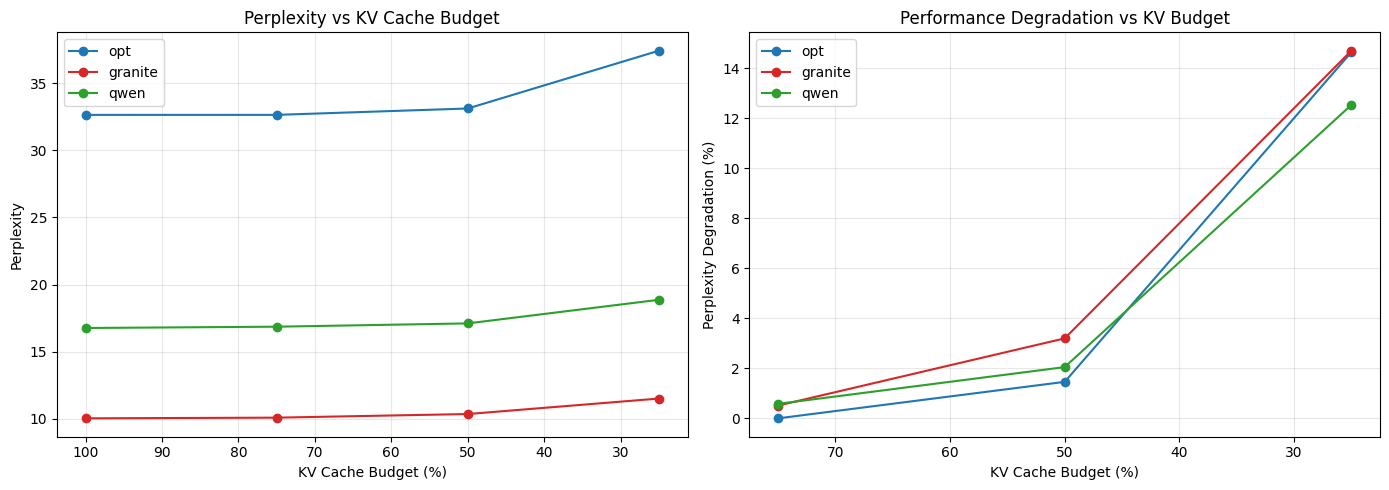

Plot saved to /content/results/kvcache_results.png


In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'opt': '#1f77b4', 'granite': '#d62728', 'qwen': '#2ca02c'}

# Plot 1: Perplexity vs KV Budget
ax1 = axes[0]
for model_name in MODELS.keys():
    subset = df[df['model'] == model_name].sort_values('kv_budget')
    ax1.plot(subset['kv_budget'] * 100, subset['perplexity'],
             marker='o', label=model_name, color=colors[model_name])
ax1.set_xlabel('KV Cache Budget (%)')
ax1.set_ylabel('Perplexity')
ax1.set_title('Perplexity vs KV Cache Budget')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.invert_xaxis()

# Plot 2: Degradation % vs KV Budget
ax2 = axes[1]
for model_name in MODELS.keys():
    subset = df[(df['model'] == model_name) & (df['kv_budget'] < 1.0)].sort_values('kv_budget')
    ax2.plot(subset['kv_budget'] * 100, subset['degradation_%'],
             marker='o', label=model_name, color=colors[model_name])
ax2.set_xlabel('KV Cache Budget (%)')
ax2.set_ylabel('Perplexity Degradation (%)')
ax2.set_title('Performance Degradation vs KV Budget')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.invert_xaxis()

plt.tight_layout()
plot_path = f'{RESULTS_DIR}/kvcache_results.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved to {plot_path}')

## Step 13 — Save Results to CSV

In [12]:
csv_path = f'{RESULTS_DIR}/kvcache_results.csv'
df.to_csv(csv_path, index=False)
print(f'Results saved to {csv_path}')
print('Done. All results are in your Google Drive under kvcache_research/results/')

Results saved to /content/results/kvcache_results.csv
Done. All results are in your Google Drive under kvcache_research/results/


## Step 14 — Attention Pattern Visualization
Visualize attention maps to show WHY KV cache eviction behaves differently per architecture

OPTModel is using SDPA attention, which currently does not support output_attentions=True.failing back to eager attention. remove warning using attn_implementation="eager".
GraniteModel is using GraniteSdpaAttention, but `torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.
Qwen2Model is using Qwen2SdpaAttention, but `torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.
The attention layers in this model are 

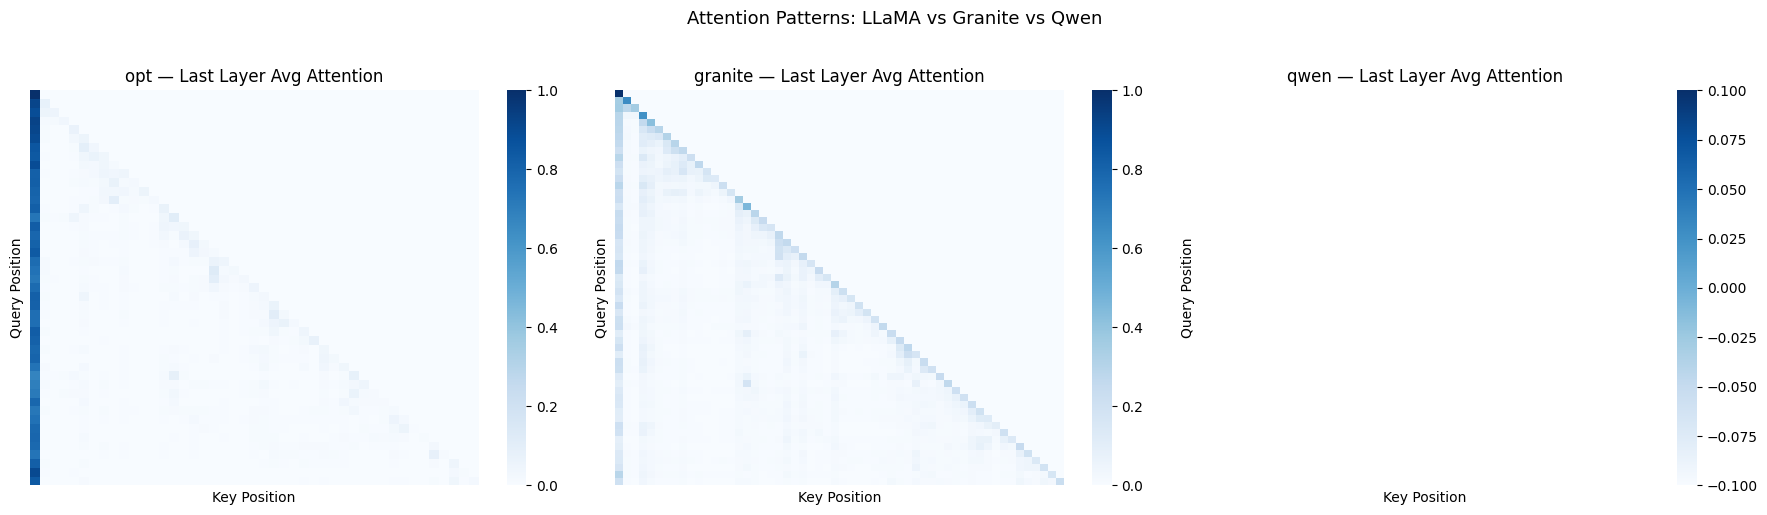

Attention plot saved to /content/results/attention_patterns.png


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sample_text = texts[0][:200]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (model_name, model) in enumerate(models.items()):
    tokenizer = tokenizers[model_name]
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    inputs = tokenizer(sample_text, return_tensors='pt',
                       truncation=True, max_length=64).to('cuda')

    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    # Average attention across all heads, last layer
    attn = outputs.attentions[-1]  # [batch, heads, seq, seq]
    avg_attn = attn[0].mean(dim=0).cpu().float().numpy()  # [seq, seq]

    ax = axes[idx]
    sns.heatmap(avg_attn, ax=ax, cmap='Blues', xticklabels=False, yticklabels=False)
    ax.set_title(f'{model_name} — Last Layer Avg Attention')
    ax.set_xlabel('Key Position')
    ax.set_ylabel('Query Position')

plt.suptitle('Attention Patterns: LLaMA vs Granite vs Qwen', y=1.02, fontsize=13)
plt.tight_layout()
attn_path = f'{RESULTS_DIR}/attention_patterns.png'
plt.savefig(attn_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Attention plot saved to {attn_path}')

## Step 15 — Attention Sink Concentration Score
Compute per-layer attention sink scores and correlate with KV cache degradation.

Computing sink scores for opt...
  opt overall sink score: 0.6483
Computing sink scores for granite...
  granite overall sink score: 0.6542
Computing sink scores for qwen...


/tmp/ipykernel_958/3675929145.py:46: RuntimeWarning: Mean of empty slice
  overall = np.nanmean(sink_scores[model_name])
/tmp/ipykernel_958/3675929145.py:63: RuntimeWarning: Mean of empty slice
  overall_sink = {m: np.nanmean(s) for m, s in sink_scores.items()}


  qwen overall sink score: nan


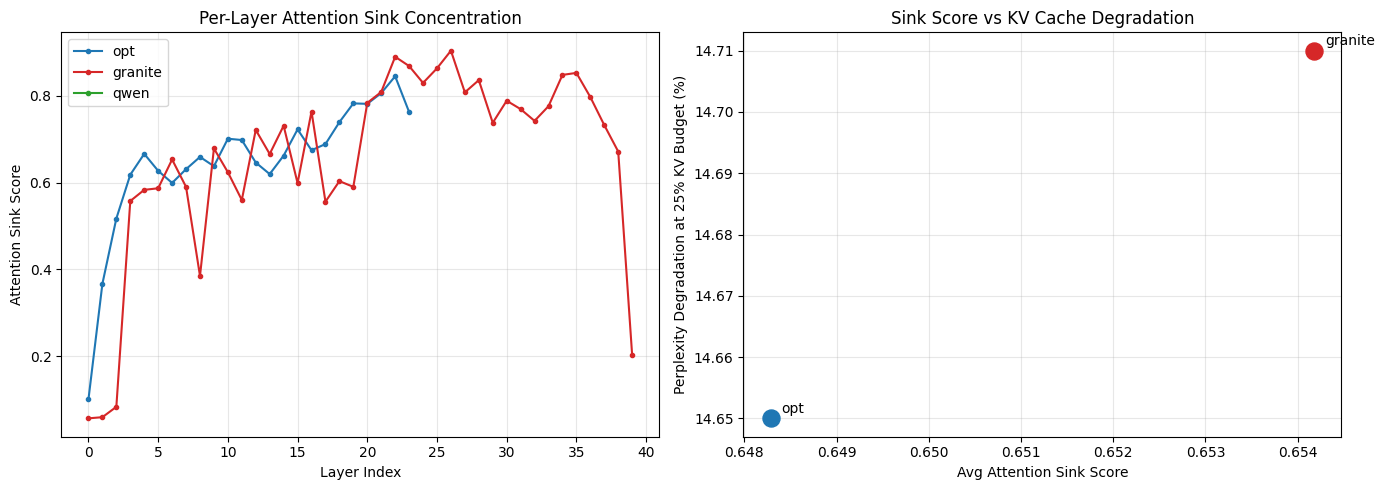

Sink analysis saved.


In [17]:
# ── Step 15: Attention Sink Concentration Score ━━━━━━━━━━━━━━━━━━━━━━━━━━

import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def compute_sink_score(model, tokenizer, texts, n_samples=20):
    model.eval()
    layer_scores = None
    count = 0
    # Get the device of the model (handles cases where model is split across devices)
    device = next(model.parameters()).device

    with torch.no_grad():
        for text in texts[:n_samples]:
            inputs = tokenizer(text, return_tensors='pt',
                             truncation=True, max_length=64).to(device)
            if inputs['input_ids'].shape[1] < 10:
                continue

            outputs = model(**inputs, output_attentions=True)
            attentions = outputs.attentions

            scores = []
            for layer_attn in attentions:
                avg = layer_attn[0].mean(dim=0)
                sink_fraction = avg[:, 0].mean().item()
                scores.append(sink_fraction)

            if layer_scores is None:
                layer_scores = np.array(scores)
            else:
                layer_scores += np.array(scores)
            count += 1

    return layer_scores / count

sink_scores = {}
for model_name, model in models.items():
    print(f'Computing sink scores for {model_name}...')
    tokenizer = tokenizers[model_name]
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    sink_scores[model_name] = compute_sink_score(model, tokenizer, texts)
    overall = np.nanmean(sink_scores[model_name])
    print(f'  {model_name} overall sink score: {overall:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
for model_name, scores in sink_scores.items():
    ax1.plot(range(len(scores)), scores,
             label=model_name, color=colors[model_name], marker='o', markersize=3)
ax1.set_xlabel('Layer Index')
ax1.set_ylabel('Attention Sink Score')
ax1.set_title('Per-Layer Attention Sink Concentration')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
degradation_25 = {row['model']: row['degradation_%'] for _, row in df[df['kv_budget'] == 0.25].iterrows()}
overall_sink = {m: np.nanmean(s) for m, s in sink_scores.items()}

for model_name in models.keys():
    ax2.scatter(overall_sink[model_name], degradation_25[model_name],
                label=model_name, color=colors[model_name], s=150, zorder=5)
    ax2.annotate(model_name, (overall_sink[model_name], degradation_25[model_name]),
                 textcoords='offset points', xytext=(8, 4), fontsize=10)

ax2.set_xlabel('Avg Attention Sink Score')
ax2.set_ylabel('Perplexity Degradation at 25% KV Budget (%)')
ax2.set_title('Sink Score vs KV Cache Degradation')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/sink_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Pad arrays to save as DataFrame (handles different layer counts)
max_layers = max(len(s) for s in sink_scores.values())
sink_dict_padded = {
    m: np.pad(s.astype(float), (0, max_layers - len(s)), constant_values=np.nan)
    for m, s in sink_scores.items()
}
sink_df = pd.DataFrame(sink_dict_padded)
sink_df.to_csv(f'{RESULTS_DIR}/sink_scores.csv')
print(f'Sink analysis saved.')

## Step 16 — Save Results to Google Drive
Backs up all plots, CSVs, and this notebook before the Colab session expires.

In [ ]:
import shutil, os
from datetime import datetime

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
DRIVE_SAVE = f'/content/drive/MyDrive/LLM_OPTIMIZATION_STUDY/run_{timestamp}'
os.makedirs(f'{DRIVE_SAVE}/data', exist_ok=True)
os.makedirs(f'{DRIVE_SAVE}/graphs', exist_ok=True)

# Copy CSVs to data/
for f in os.listdir(RESULTS_DIR):
    src = f'{RESULTS_DIR}/{f}'
    if f.endswith('.csv'):
        shutil.copy(src, f'{DRIVE_SAVE}/data/{f}')
        print(f'  ✓ data/{f}')
    elif f.endswith('.png'):
        shutil.copy(src, f'{DRIVE_SAVE}/graphs/{f}')
        print(f'  ✓ graphs/{f}')

print(f'\nSaved to Drive: {DRIVE_SAVE}')
print('Download this notebook via File → Download → Download .ipynb')
